# Visualización Avanzada
En el presente trabajo se analizarán los datos de COVID-19 que se obtienen a partir de la declaración de los casos a la Red Nacional de Vigilancia Epidemiológica (RENAVE) a través de la plataforma informática vía Web SiViES (Sistema de Vigilancia de España) que gestiona el Centro Nacional de Epidemiología (CNE). Estos datos corresponden al periodo comprendido entre el inicio de la pandemia (enero-2020) hasta el 28 de marzo de 2022.

Para realizar algunos cálculos más específicos utilizaremos datos del INE, específicamente de población por provincia y franja etaria de los últimos tres años (2020, 2021 y 2022) y los datos de polígonos que correspoden a las representaciones gráficas de las provincias de España.

**Para empezar, importamos las librerías que utilizaremos para este análisis.**

In [1]:
!pip install geopandas
!pip install dash_core_components
!pip install dash_html_components
!pip install mapclassify

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from datetime import date
from datetime import datetime
import plotly.express as px
import plotnine
from plotnine import *
import dash
import dash_core_components as dcc
import dash_html_components as html
import plotly.graph_objects as go
import folium

### Lectura de datasets
Realizamos la lectura de los datasets de Covid y provincias (previamente descargados) y realizamos unos primeros ajustes a los mismos.

Los archivos se encuentran en el mismo directorio del presente notebook.

In [3]:
covid = pd.read_csv(r'casos_hosp_uci_def_sexo_edad_provres.csv')
prv = pd.read_csv(r'provinces_es.csv')
geo_prv = r'SP_provincias.geojson'
map = gpd.read_file(geo_prv)

In [4]:
map['postal_code'] = pd.to_numeric(map['CC_2'])
map.drop(['CC_2', 'NAT2018'], axis = 'columns', inplace=True)
map.rename(columns={'NAME_1':'comunidad_autonoma',
                    'NAME_2':'provincia'}, inplace = True)

**Realizamos una pre-visualización del contenido**

In [5]:
covid.head()

,provincia_iso,sexo,grupo_edad,fecha,num_casos,num_hosp,num_uci,num_def
0,A,H,0-9,2020-01-01,0,0,0,0
1,A,H,10-19,2020-01-01,0,0,0,0
2,A,H,20-29,2020-01-01,0,0,0,0
3,A,H,30-39,2020-01-01,0,0,0,0
4,A,H,40-49,2020-01-01,0,0,0,0


In [6]:
prv.head()

,code,postal_code,name,phone_code,iso2
0,VI,1,Álava,945,ES
1,AB,2,Albacete,967,ES
2,A,3,Alacant,950,ES
3,AL,4,Almería,920,ES
4,AV,5,Ávila,924,ES


In [7]:
map.head()

,comunidad_autonoma,provincia,geometry,postal_code
0,Andalucía,Almería,"MULTIPOLYGON (((-3.03042 35.94236, -3.03042 35...",4
1,Andalucía,Cádiz,"MULTIPOLYGON (((-6.21958 36.3811, -6.21958 36....",11
2,Andalucía,Córdoba,"MULTIPOLYGON (((-5.04854 37.6369, -5.04667 37....",14
3,Andalucía,Granada,"MULTIPOLYGON (((-3.35014 36.72952, -3.35014 36...",18
4,Andalucía,Huelva,"MULTIPOLYGON (((-6.83648 37.11547, -6.83643 37...",21


**Empezamos uniendo nuestros datasets de covid y provincias**

In [8]:
cov_prv = covid.merge(prv, how='left', left_on='provincia_iso', right_on='code', suffixes=('_cov', '_prv'))

**Realizamos algunos formateos a los datos, para que nos ayuden en las visualizaciones posteriores**

In [9]:
cov_prv['periodo'] = cov_prv['fecha'].str.slice(0, 4)
cov_prv['periodo'] = pd.to_numeric(cov_prv['periodo'])
cov_prv['fecha'] = pd.to_datetime(covid['fecha'], format = '%Y-%m-%d', errors = 'coerce')
cov_prv['semana'] = cov_prv['fecha'].dt.isocalendar().week

cov_prv.drop(['name', 'phone_code', 'iso2'], axis = 'columns', inplace=True)
cov_prv.rename(columns={'grupo_edad': 'franja_etaria'}, inplace=True)
cov_prv.head()

,provincia_iso,sexo,franja_etaria,fecha,num_casos,num_hosp,num_uci,num_def,code,postal_code,periodo,semana
0,A,H,0-9,2020-01-01,0,0,0,0,A,3.0,2020,1
1,A,H,10-19,2020-01-01,0,0,0,0,A,3.0,2020,1
2,A,H,20-29,2020-01-01,0,0,0,0,A,3.0,2020,1
3,A,H,30-39,2020-01-01,0,0,0,0,A,3.0,2020,1
4,A,H,40-49,2020-01-01,0,0,0,0,A,3.0,2020,1


**Realizamos la importación de los datos de población de cada provincia, correspondientes a los años 2020, 2021 y 2022.**

**Luego, unimos las tres fuentes en un único dataset.**

In [10]:
pob_esp2020 = pd.read_csv(r'PoblacionEspana-Provincia_2020.csv', 
                      sep=';', 
                      encoding='latin-1')
pob_esp2021 = pd.read_csv(r'PoblacionEspana-Provincia_2021.csv', 
                      sep=';', 
                      encoding='latin-1')
pob_esp2022 = pd.read_csv(r'PoblacionEspana-Provincia_2022.csv', 
                      sep=';', 
                      encoding='latin-1')
pob_esp = pd.concat([pob_esp2020, pob_esp2021, pob_esp2022])
pob_esp.head(3)

,Edad Simple,Provincias,Sexo,Periodo,Total
0,0 años,02 Albacete,Hombres,1 de julio de 2020,"1.475,500000"
1,0 años,02 Albacete,Mujeres,1 de julio de 2020,"1.352,500000"
2,0 años,03 Alicante/Alacant,Hombres,1 de julio de 2020,"6.962,000000"


**A continuación, realizamos algunos formateos al dataset para dejarlo a punto para el análisis**

In [11]:
pob_esp.rename(columns={'Edad Simple': 'edad', 
                        'Provincias': 'provincia', 
                        'Sexo':'sexo', 
                        'Periodo':'periodo', 
                        'Total':'total'}, 
               inplace=True)

In [12]:
pob_esp['total'] = pob_esp['total'].str.replace(',','|')
pob_esp['total'] = pob_esp['total'].str.replace('.','')
pob_esp['total'] = pob_esp['total'].str.replace('|','.')
pob_esp['total'] = pob_esp['total'].astype(float)

In [13]:
pob_esp['postal_code'] = pob_esp['provincia'].str.slice(0, 2)
pob_esp['postal_code'] = pd.to_numeric(pob_esp['postal_code'])

In [14]:
pob_esp.loc[pob_esp['sexo'] == 'Hombres', 'sexo'] = 'H'
pob_esp.loc[pob_esp['sexo'] == 'Mujeres', 'sexo'] = 'M'

In [15]:
datos = pob_esp['edad'].str.split(expand=True)
datos.columns = ['edad2', 'edad3', 'edad4', 'edad5']
pob_esp = pd.concat([pob_esp, datos], axis=1)
pob_esp.drop(['edad3', 'edad4', 'edad5'], axis = 'columns', inplace=True)
pob_esp['edad2'] = pd.to_numeric(pob_esp['edad2'])
pob_esp.head(3)

,edad,provincia,sexo,periodo,total,postal_code,edad2
0,0 años,02 Albacete,H,1 de julio de 2020,1475.5,2,0
1,0 años,02 Albacete,M,1 de julio de 2020,1352.5,2,0
2,0 años,03 Alicante/Alacant,H,1 de julio de 2020,6962.0,3,0


In [16]:
def franja_etaria(edad):
    if edad < 10:
        franja = '0-9'
    elif edad < 20:
        franja = '10-19'
    elif edad < 30:
        franja = '20-29'
    elif edad < 40:
        franja = '30-39'
    elif edad < 50:
        franja = '40-49'
    elif edad < 60:
        franja = '50-59'
    elif edad < 70:
        franja = '60-69'
    elif edad < 80:
        franja = '70-79'
    else:
        franja = '80+'
    return franja

In [17]:
pob_esp['franja_etaria'] = pob_esp['edad2'].apply(franja_etaria)

In [18]:
separado = pob_esp['periodo'].str.split(' ', expand=True)
pob_esp['periodo']= separado[4]
pob_esp['periodo'] = pd.to_numeric(pob_esp['periodo'])
pob_esp.head(3)

,edad,provincia,sexo,periodo,total,postal_code,edad2,franja_etaria
0,0 años,02 Albacete,H,2020,1475.5,2,0,0-9
1,0 años,02 Albacete,M,2020,1352.5,2,0,0-9
2,0 años,03 Alicante/Alacant,H,2020,6962.0,3,0,0-9


**A continuación, agrupamos los datos de poblacion por año y provincia, para cruzarlo con nuestro dataset de casos de Covid.**

In [19]:
poblacion = pob_esp.groupby(['periodo', 
                             'provincia', 
                             'postal_code', 
                            ]).agg({'total':'sum'}).reset_index()
poblacion.head()

,periodo,provincia,postal_code,total
0,2020,01 Araba/Álava,1,3.301570e+05
1,2020,02 Albacete,2,3.890275e+05
2,2020,03 Alicante/Alacant,3,1.889768e+06
3,2020,04 Almería,4,7.171430e+05
4,2020,05 Ávila,5,1.580949e+05


### Incidencia Acumulada a 14 días por cada 100.000 habitantes
Calculamos la IA a 14 días por cada cien mil habitantes.

In [20]:
sum_cov = cov_prv.groupby(['fecha', 'periodo']).agg({'num_casos':'sum'})

In [21]:
def buildLaggedFeatures(s, lag=2, dropna=True):
    if type(s) is pd.DataFrame:
        new_dict={}
        for col_name in s:
            new_dict[col_name]=s[col_name]
            for l in range(1,lag+1):
                new_dict['%s_%d' %(col_name,l)]=s[col_name].shift(l)
        res=pd.DataFrame(new_dict,index=s.index)

    elif type(s) is pd.Series:
        the_range=range(lag+1)
        res=pd.concat([s.shift(i) for i in the_range],axis=1)
        res.columns=['_%d' %i for i in the_range]
    else:
        print ('Only works for DataFrame or Series')
        return None
    if dropna:
        return res.dropna()
    else:
        return res

In [22]:
casos_trend = buildLaggedFeatures(sum_cov,lag=13,dropna=False)

In [23]:
casos_trend = casos_trend.reset_index()

In [24]:
casos_trend2 = pd.melt(casos_trend, 
                       id_vars=['fecha', 'periodo'], 
                       value_vars=['num_casos', 'num_casos_1', 'num_casos_2','num_casos_3', 'num_casos_4', 
                                   'num_casos_5', 'num_casos_6', 'num_casos_7', 'num_casos_8', 'num_casos_9', 
                                   'num_casos_10', 'num_casos_11', 'num_casos_12', 'num_casos_13'])

In [25]:
casos_trend2 = casos_trend2.groupby(['fecha', 'periodo']).agg({'value':'sum'}).reset_index()
pob = poblacion.groupby(['periodo']).agg({'total':'sum'}).reset_index()
casos_trend_pob = casos_trend2.merge(pob, how='left', left_on='periodo', right_on='periodo')
casos_trend_pob['ia14d'] = casos_trend_pob['value']/casos_trend_pob['total']*100000
casos_trend_pob.head()

,fecha,periodo,value,total,ia14d
0,2020-01-01,2020,0.0,4.735568e+07,0.0
1,2020-01-02,2020,0.0,4.735568e+07,0.0
2,2020-01-03,2020,0.0,4.735568e+07,0.0
3,2020-01-04,2020,0.0,4.735568e+07,0.0
4,2020-01-05,2020,0.0,4.735568e+07,0.0


**Visualizamos la tendencia de la IA**

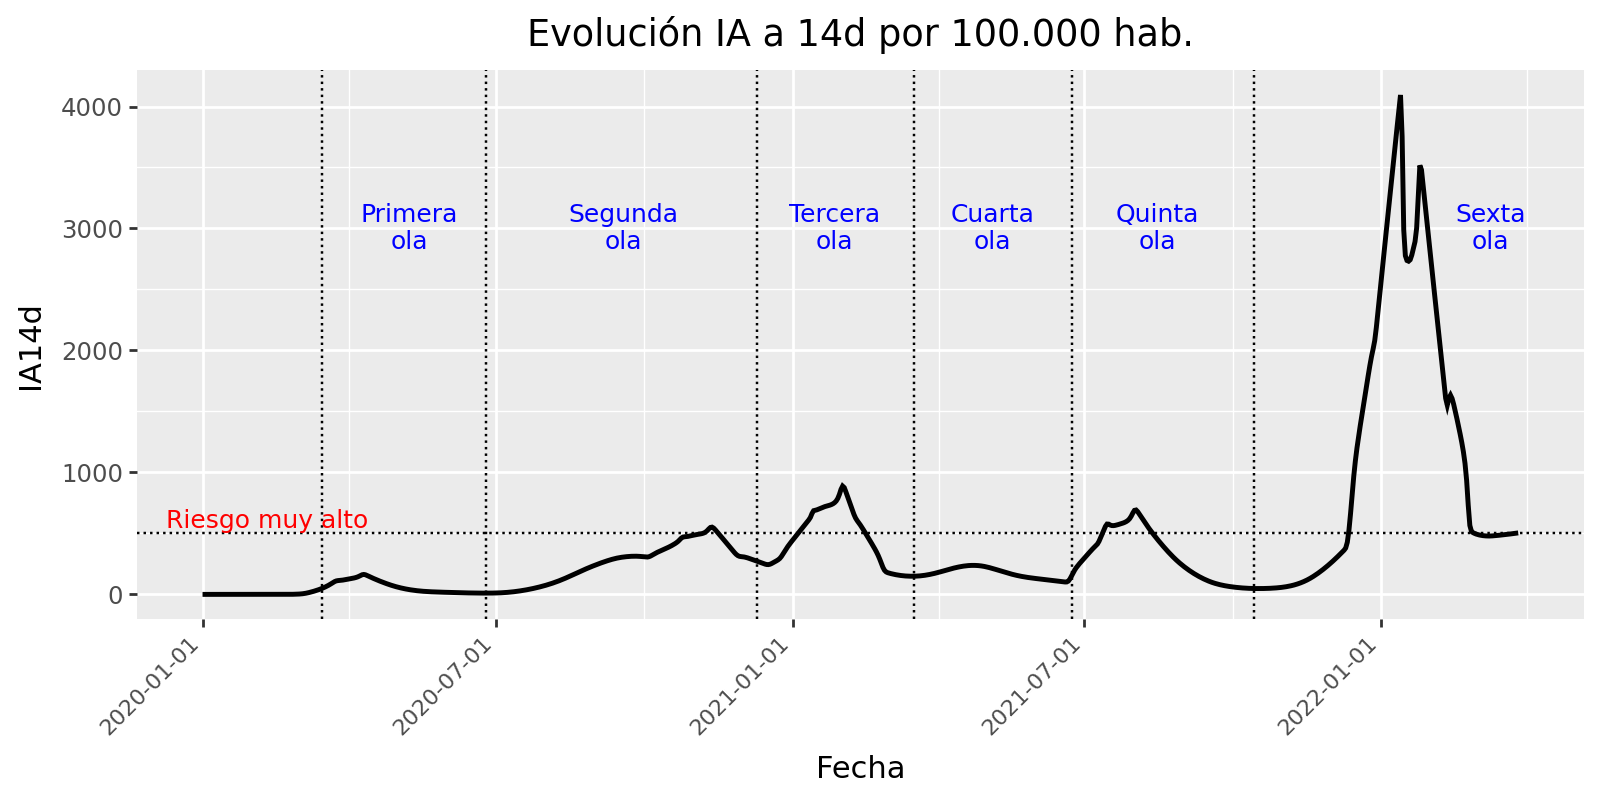

In [26]:
(
    ggplot(casos_trend_pob)  
    + aes(x = 'fecha', 
          y = 'ia14d')   
    #+ geom_rect(data=df, mapping=aes(xmin=df.x1, xmax=df.x2, ymin=0, ymax=80000, fill=df.r), color="black", alpha=0.5)
    + geom_smooth(method = "lowess", 
                  span = 0.05)

    #+ geom_hline(yintercept = 500, size = 0.5, linetype = 'dotted')
    + geom_hline(yintercept = 500, size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2020-03-15', size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2020-06-25', size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2020-12-10', size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2021-03-17', size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2021-06-23', size = 0.5, linetype = 'dotted')
    + geom_vline(xintercept = '2021-10-14', size = 0.5, linetype = 'dotted')
    + theme(figure_size=(8, 4),
            axis_text_x = element_text(angle = 45,
                                      hjust = 1,
                                      size = 8))
    + annotate('text', x='2020-02-10', y=600, label='Riesgo muy alto', size=9, color='red')
    + annotate('text', x='2020-05-08', y=3000, label='Primera\nola', size=9, color='blue')
    + annotate('text', x='2020-09-18', y=3000, label='Segunda\nola', size=9, color='blue')
    + annotate('text', x='2021-01-27', y=3000, label='Tercera\nola', size=9, color='blue')
    + annotate('text', x='2021-05-05', y=3000, label='Cuarta\nola', size=9, color='blue')
    + annotate('text', x='2021-08-15', y=3000, label='Quinta\nola', size=9, color='blue')
    + annotate('text', x='2022-03-10', y=3000, label='Sexta\nola', size=9, color='blue')
    + labs(title='Evolución IA a 14d por 100.000 hab.', x='Fecha', y='IA14d')
)


Se visualizan picos en determinados momentos de la pandemia, que corresponden a las diferentes olas, notándose especialmente la correspondiente a la sexta ola de la pandemia.

A continuación, incluimos un gráfico interactivo para visualizar la tendencia de casos por provincia:

In [27]:
prv_trend = cov_prv.merge(map, how='left', left_on='postal_code', right_on='postal_code')
prv_trnd = prv_trend.groupby(['provincia', 'fecha']).agg({'num_casos':'sum'}).reset_index()
prv_trnd['fecha'] = pd.to_datetime(prv_trnd['fecha'], format = '%Y-%m-%d', errors = 'coerce')

df_sp = prv_trnd.groupby(['fecha']).agg({'num_casos':'sum'}).reset_index()
df_sp['provincia']='All'
df_dash = pd.concat([prv_trnd, df_sp])
available_prv = df_dash['provincia'].unique()


In [28]:
app = dash.Dash()
app.layout = html.Div([
    dcc.Dropdown(
        id='demo-dropdown',
        options=[{'label': k, 'value': k} for k in available_prv],
        value=['All'],
        multi=True
    ),

    html.Hr(),
    dcc.Graph(id='display-selected-values'),

])

@app.callback(
    dash.dependencies.Output('display-selected-values', 'figure'),
    [dash.dependencies.Input('demo-dropdown', 'value')])

def update_output(value):
    ts = df_dash[df_dash["provincia"].isin(value)]
    fig = px.line(ts, x="fecha", y="num_casos", color="provincia")
    return fig


if __name__ == '__main__':
    app.run()

### Evolución de los casos por sexo

In [29]:
trnd_sexo = cov_prv.groupby(['fecha', 'sexo']).agg({'num_casos':'sum', 
                                                   'num_hosp':'sum', 
                                                   'num_uci':'sum', 
                                                   'num_def':'sum'
                                                  }).reset_index()
trnd_sexo = trnd_sexo[trnd_sexo['sexo']!='NC']

**Visualizamos la evolución de los casos por sexo**

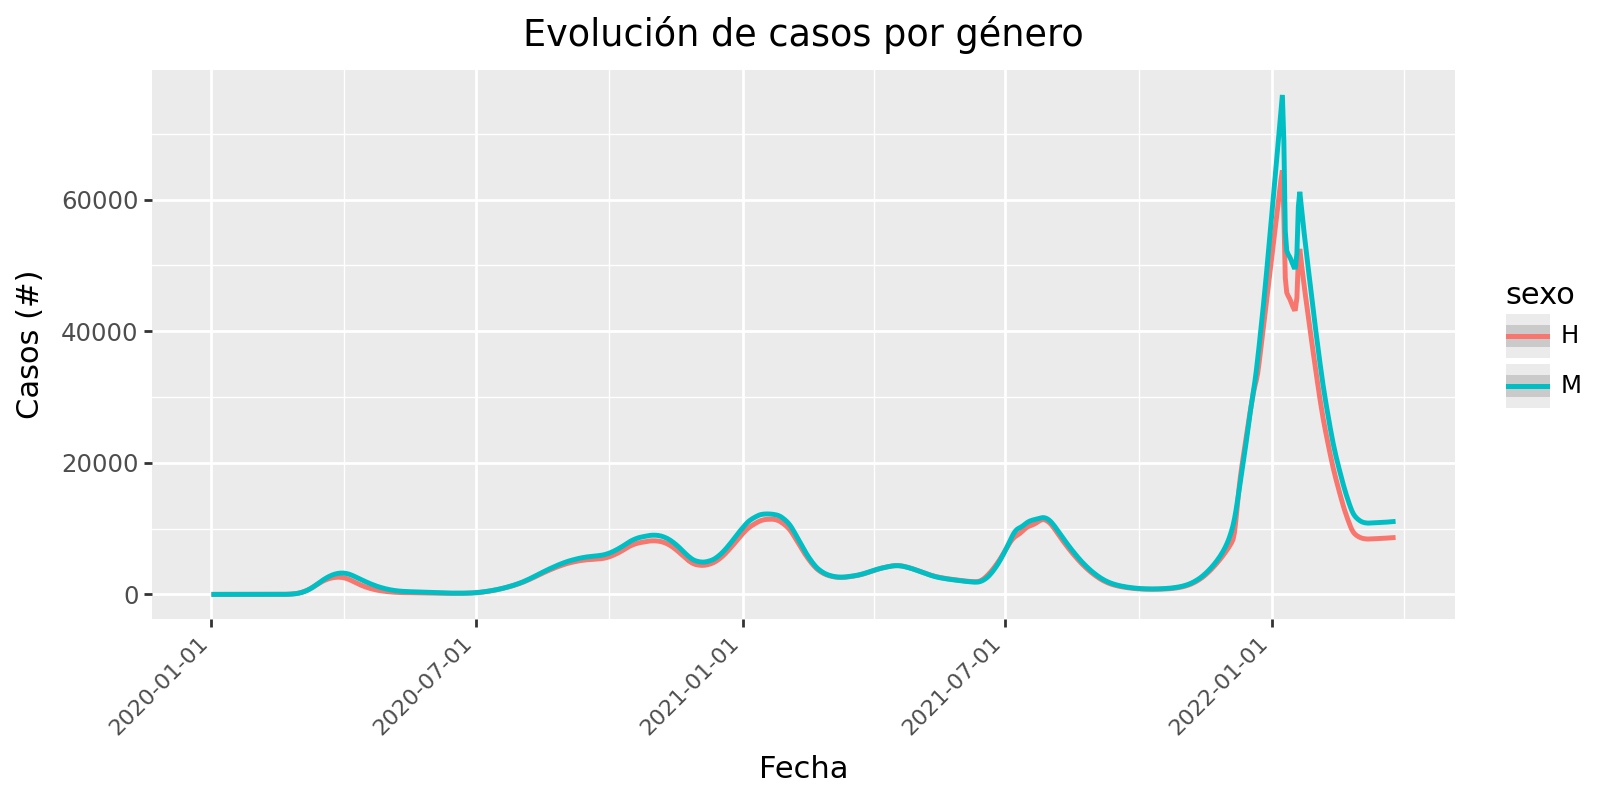

In [30]:
(
    ggplot(trnd_sexo)
    + aes(x = 'fecha', 
          y = 'num_casos',
          color = 'sexo') 
    + geom_smooth(method = 'lowess', 
                  span = 0.05)
    + theme(figure_size=(8, 4),
            axis_text_x = element_text(angle = 45,
                                      hjust = 1,
                                      size = 8))
    + labs(title='Evolución de casos por género', x='Fecha', y='Casos (#)')
)

Cabe destacar una marcada diferencia entre hombres y mujeres durante la última ola, cuyos números de casos femeninos superan a los casos masculinos.

### Franja etaria
Es interesante mirar el comportamiento del virus teniendo en cuenta la franja etaria de la población afectada.

In [31]:
casos_franja = cov_prv[cov_prv['franja_etaria']!='NC']

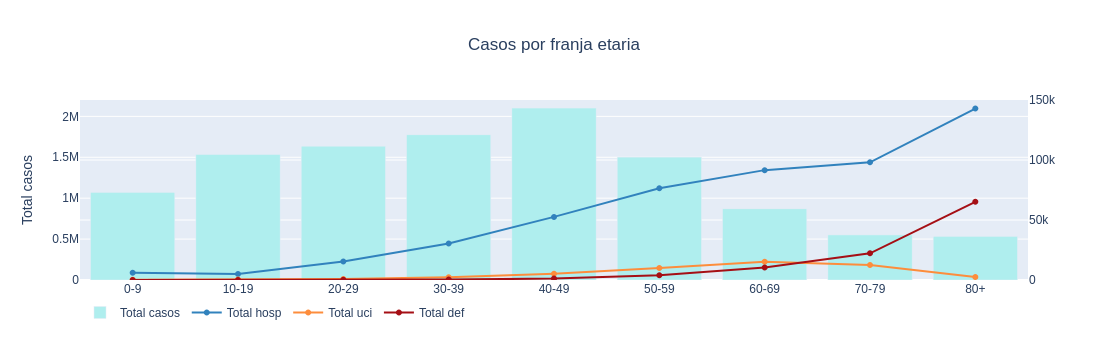

In [32]:
summed_values = casos_franja.groupby(by=['franja_etaria'], as_index=False).sum(numeric_only=True)
franja_order_mapping = {'0-9': 0, 
                        '10-19': 1, 
                        '20-29': 2,
                        '30-39': 3,
                        '40-49': 4,
                        '50-59': 5,
                        '60-69': 6,
                        '70-79': 7,
                        '80+': 8}
summed_values['order'] = summed_values['franja_etaria'].apply(lambda franja_etaria: franja_order_mapping[franja_etaria])
summed_values = summed_values.sort_values(by="order")

franja = summed_values['franja_etaria'].values
num_casos = summed_values['num_casos'].values
num_hosp = summed_values['num_hosp'].values
num_uci = summed_values['num_uci'].values
num_def = summed_values['num_def'].values

fig = go.Figure(
    data=go.Bar(
        x=franja,
        y=num_casos,
        name='Total casos',
        marker=dict(color='paleturquoise'),
    )
)

fig.add_trace(
    go.Scatter(
        x=franja,
        y=num_hosp,
        yaxis='y2',
        name='Total hosp',
        marker=dict(color='#3182bd'),
    ), 
)

fig.add_trace(
    go.Scatter(
        x=franja,
        y=num_uci,
        yaxis='y2',
        name='Total uci',
        marker=dict(color='#fd8d3c'),
    )    
)

fig.add_trace(
    go.Scatter(
        x=franja,
        y=num_def,
        yaxis='y2',
        name='Total def',
        marker=dict(color='#a50f15'),
    )    
)

fig.update_layout(
    title_text='Casos por franja etaria', 
    title_x=0.5,
    legend=dict(orientation='h'),
    yaxis=dict(
        title=dict(text='Total casos'),
        side='left',
        range=[0, 2200000],
    ),
    yaxis2=dict(
        title=dict(text=''),
        side='right',
        range=[0, 150000],
        overlaying='y',
        tickmode='auto',
    ),
)

fig.show()

**Este gráfico nos permite comparar de un vistazo cómo fue el comportamiento del virus por franja etaria, en términos de contagios, hospitalizaciones, ingreso en UCI y defunciones.**

Podemos resumir algunos puntos importantes:

- La mayor cantidad de casos se concentró en la franja de jóvenes y adultos (0 a 49 años), habiendo una menor cantidad en la franja de adultos mayores. Esto puede ser debido a la población en esas franjas etarias. Por ello, analizaremos ratios por población más adelante.
- Sin embargo, los casos de hospitalizaciones son mayores cuanto mayor es la franja etaria, como era de esperarse.
- Cabe destacar que el comportamiento de ingresos en UCI no sigue la misma tendencia, ya que se puede apreciar que el pico se encuentra en la franja de 60 a 69 años, decreciendo nuevamente en franjas superiores. Esto puede deberse a políticas de ingreso a UCI.
- El comportamiento de defunciones sigue el mismo comportamiento de hospitalizaciones. Mayor es el número de defunciones cuanto mayor sea el rango de edad.

**Tengamos en cuenta la población de cada franja etaria y analicemos algunos indicadores:**

In [33]:
pob_periodo_franja = pob_esp.groupby(['periodo','franja_etaria']).agg({'total':'sum'}).reset_index()

In [34]:
casos_franja_periodo = cov_prv.groupby(['periodo', 
                                     'franja_etaria']).agg({'num_casos':'sum',
                                                   'num_hosp':'sum', 
                                                   'num_uci':'sum', 
                                                   'num_def':'sum'
                                                  }).reset_index()

In [35]:
casos_franja_periodo = casos_franja_periodo.merge(pob_periodo_franja, 
                                            how='left', 
                                            left_on=['periodo', 'franja_etaria'], 
                                            right_on=['periodo', 'franja_etaria'])

In [36]:
casos_franja_periodo = casos_franja_periodo.groupby(['franja_etaria']).agg({'num_casos':'sum', 
                                                               'num_hosp':'sum', 
                                                               'num_uci':'sum', 
                                                               'num_def':'sum', 
                                                               'total':'mean'
                                                              }).reset_index()

In [37]:
casos_franja_periodo.rename(columns={'total':'poblacion'}, inplace=True)

In [38]:
casos_franja_periodo = casos_franja_periodo[casos_franja_periodo['franja_etaria']!='NC']
casos_franja_periodo['ratio_casos'] = casos_franja_periodo['num_casos']/casos_franja_periodo['poblacion']
casos_franja_periodo['ratio_hospitalizado'] = casos_franja_periodo['num_hosp']/casos_franja_periodo['num_casos']
casos_franja_periodo['ratio_uci'] = casos_franja_periodo['num_uci']/casos_franja_periodo['num_casos']
casos_franja_periodo['letalidad'] = casos_franja_periodo['num_def']/casos_franja_periodo['num_casos']

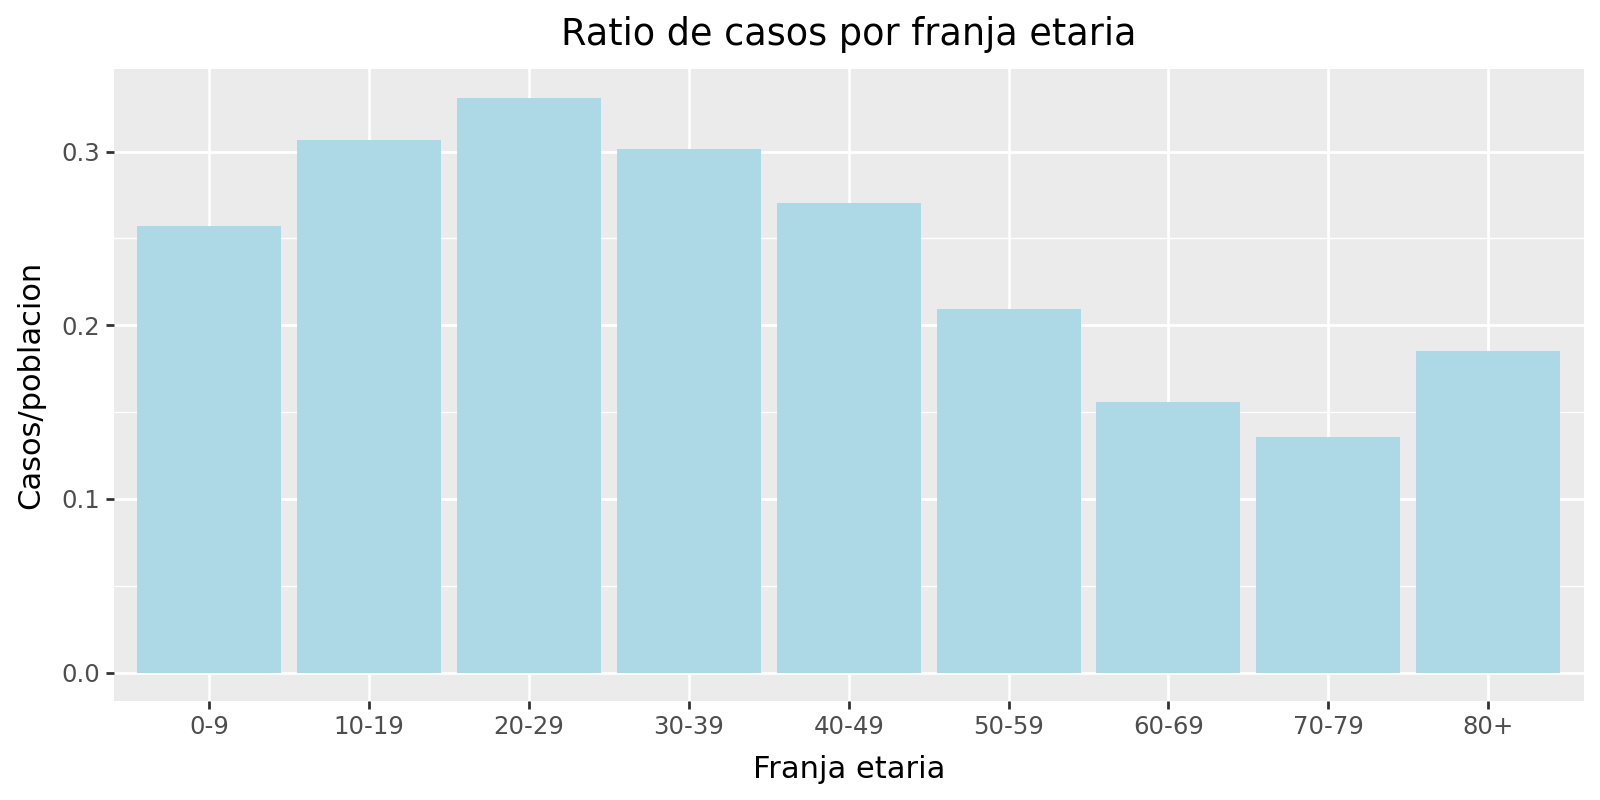

In [39]:
(
    ggplot(casos_franja_periodo)  
    + aes(x='franja_etaria', 
          y='ratio_casos')
    + geom_bar(position = "dodge",
               stat = "identity",
               fill='lightblue') 
    + labs(title='Ratio de casos por franja etaria', x='Franja etaria', y='Casos/poblacion')
    + theme(figure_size=(8, 4))
)


Antes veíamos que la mayor cantidad de casos se concentraba en la poblacion joven y adulta, mientras que los adultos mayores tenían la menor cantidad de casos. Con este gráfico podemos notar que la cantidad de contagios de la población de adultos mayores es superior con respecto a su población.

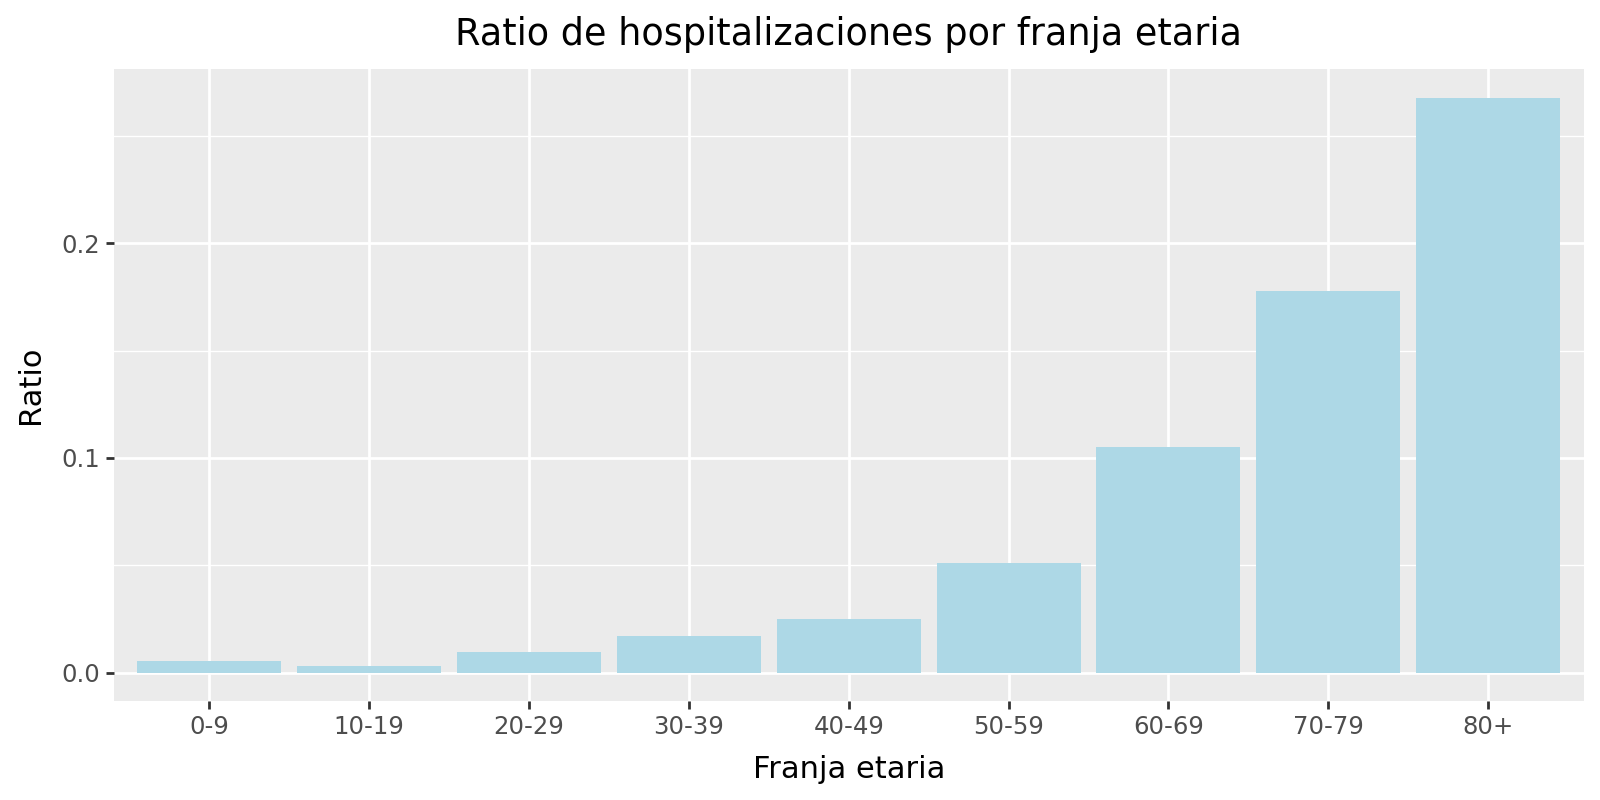

In [40]:
(
    ggplot(casos_franja_periodo)  
    + aes(x='franja_etaria', 
          y='ratio_hospitalizado')
    + geom_bar(position = "dodge",
               stat = "identity",
               fill='lightblue') 
    + labs(title='Ratio de hospitalizaciones por franja etaria', x='Franja etaria', y='Ratio')
    + theme(figure_size=(8, 4))
)


Aquí vemos claramente que el ratio de hospitalizaciones por población es mayor en la franja de 60 años o más.

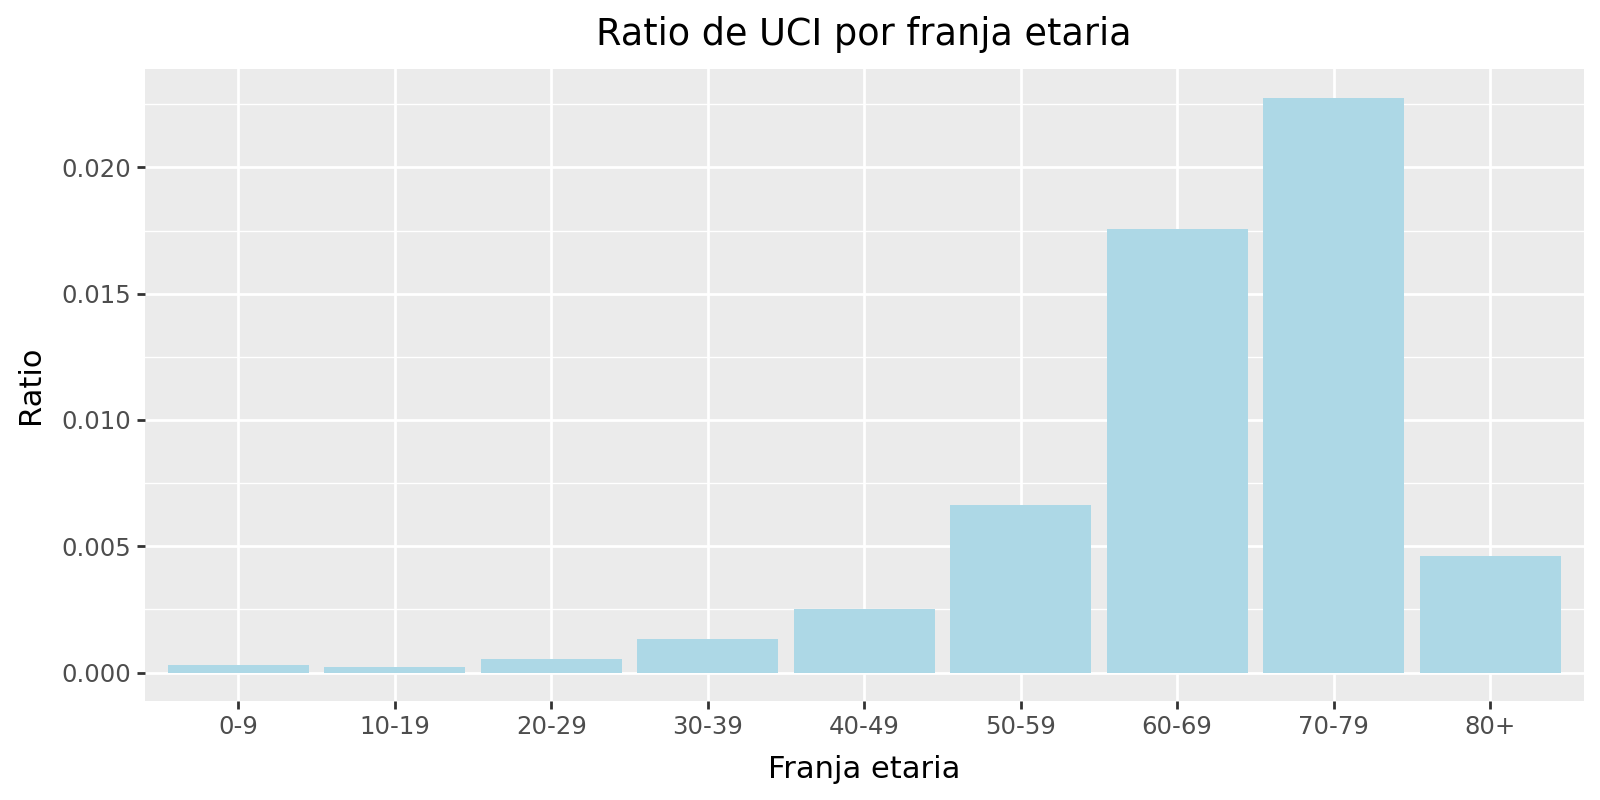

In [41]:
(
    ggplot(casos_franja_periodo)  
    + aes(x='franja_etaria', 
          y='ratio_uci')
    + geom_bar(position = "dodge",
               stat = "identity",
               fill='lightblue') 
    + labs(title='Ratio de UCI por franja etaria', x='Franja etaria', y='Ratio')
    + theme(figure_size=(8, 4))
)


Similar comportamiento a lo que veíamos en cantidad de casos.

Sostenemos el supuesto de que esto podría deberse a políticas de ingreso a UCI.

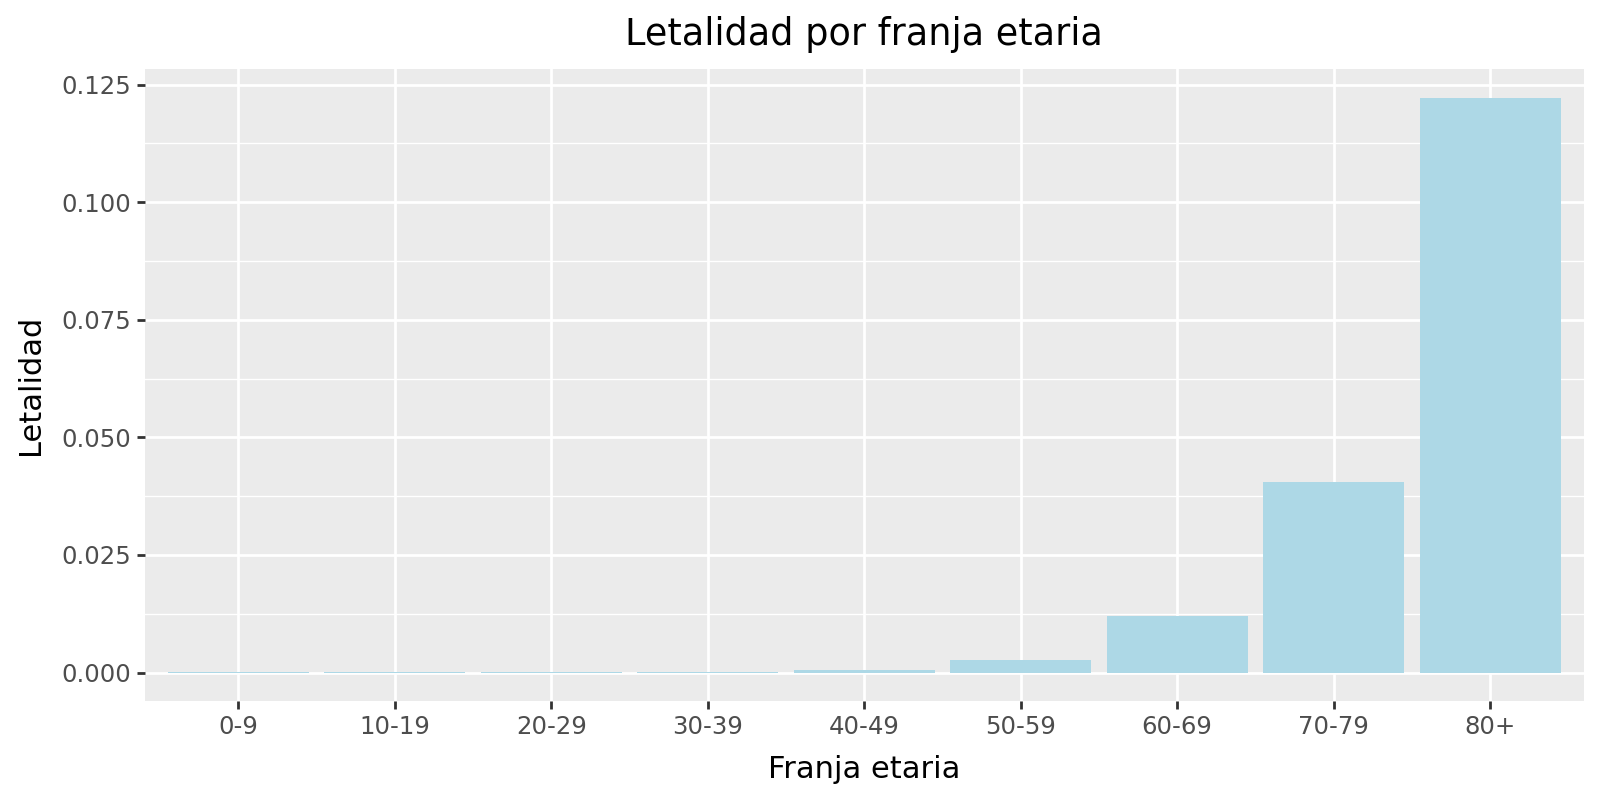

In [42]:
(
    ggplot(casos_franja_periodo)  
    + aes(x='franja_etaria', 
          y='letalidad')
    + geom_bar(position = "dodge",
               stat = "identity",
               fill='lightblue') 
    + labs(title='Letalidad por franja etaria', x='Franja etaria', y='Letalidad')
    + theme(figure_size=(8, 4))
)

Vemos claramente que la mayor letalidad está en la franja de 60 años en adelante, alcanzando inclusive el 12% en la franja de 80 años o más.

### Franja etaria y sexo
Hacemos el drill down por sexo para analizar si existen patrones diferentes entre hombres y mujeres

In [43]:
pob_periodo_franja_sexo = pob_esp.groupby(['periodo','franja_etaria', 'sexo']).agg({'total':'sum'}).reset_index()

In [44]:
casos_franja_sexo = cov_prv.groupby(['periodo', 
                                     'franja_etaria', 
                                     'sexo']).agg({'num_casos':'sum',
                                                   'num_hosp':'sum', 
                                                   'num_uci':'sum', 
                                                   'num_def':'sum'
                                                  }).reset_index()

In [45]:
casos_franja_sexo = casos_franja_sexo.merge(pob_periodo_franja_sexo, 
                                            how='left', 
                                            left_on=['periodo', 'franja_etaria', 'sexo'], 
                                            right_on=['periodo', 'franja_etaria', 'sexo'])

In [46]:
casos_franja_sexo = casos_franja_sexo.groupby(['franja_etaria'
                                               , 'sexo']).agg({'num_casos':'sum', 
                                                               'num_hosp':'sum', 
                                                               'num_uci':'sum', 
                                                               'num_def':'sum', 
                                                               'total':'mean'
                                                              }).reset_index()

In [47]:
casos_franja_sexo.rename(columns={'total':'poblacion'}, inplace=True)

In [48]:
casos_franja_sexo = casos_franja_sexo[casos_franja_sexo['franja_etaria']!='NC']
casos_franja_sexo = casos_franja_sexo[casos_franja_sexo['sexo']!='NC']
casos_franja_sexo['ratio_casos'] = casos_franja_sexo['num_casos']/casos_franja_sexo['poblacion']
casos_franja_sexo['ratio_hospitalizado'] = casos_franja_sexo['num_hosp']/casos_franja_sexo['num_casos']
casos_franja_sexo['ratio_uci'] = casos_franja_sexo['num_uci']/casos_franja_sexo['num_casos']
casos_franja_sexo['letalidad'] = casos_franja_sexo['num_def']/casos_franja_sexo['num_casos']


**Visualizamos el acumulado de casos por franja etaria discriminado por hombres/mujeres**

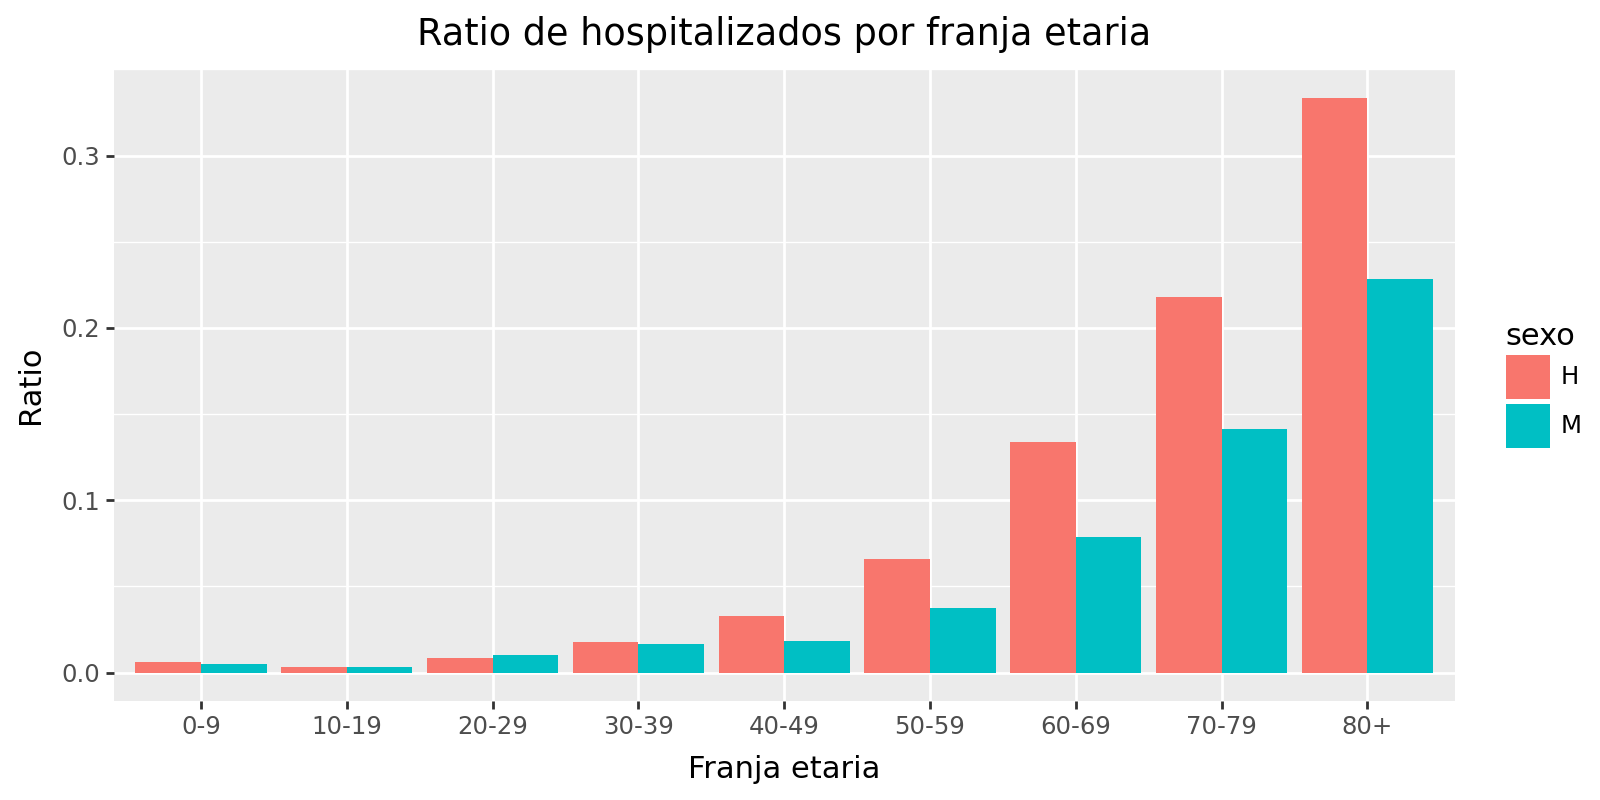

In [49]:
(
    ggplot(casos_franja_sexo)  
    + aes('franja_etaria', 
          'ratio_hospitalizado',
          fill = 'sexo')
    + geom_bar(position = "dodge",
               stat = "identity") 
    + labs(title='Ratio de hospitalizados por franja etaria', x='Franja etaria', y='Ratio')
    + theme(figure_size=(8, 4))
)


En casi todas las franjas etarias, vemos un mayor ratio de hombres hospitalizados, incrementándose a mayor edad.

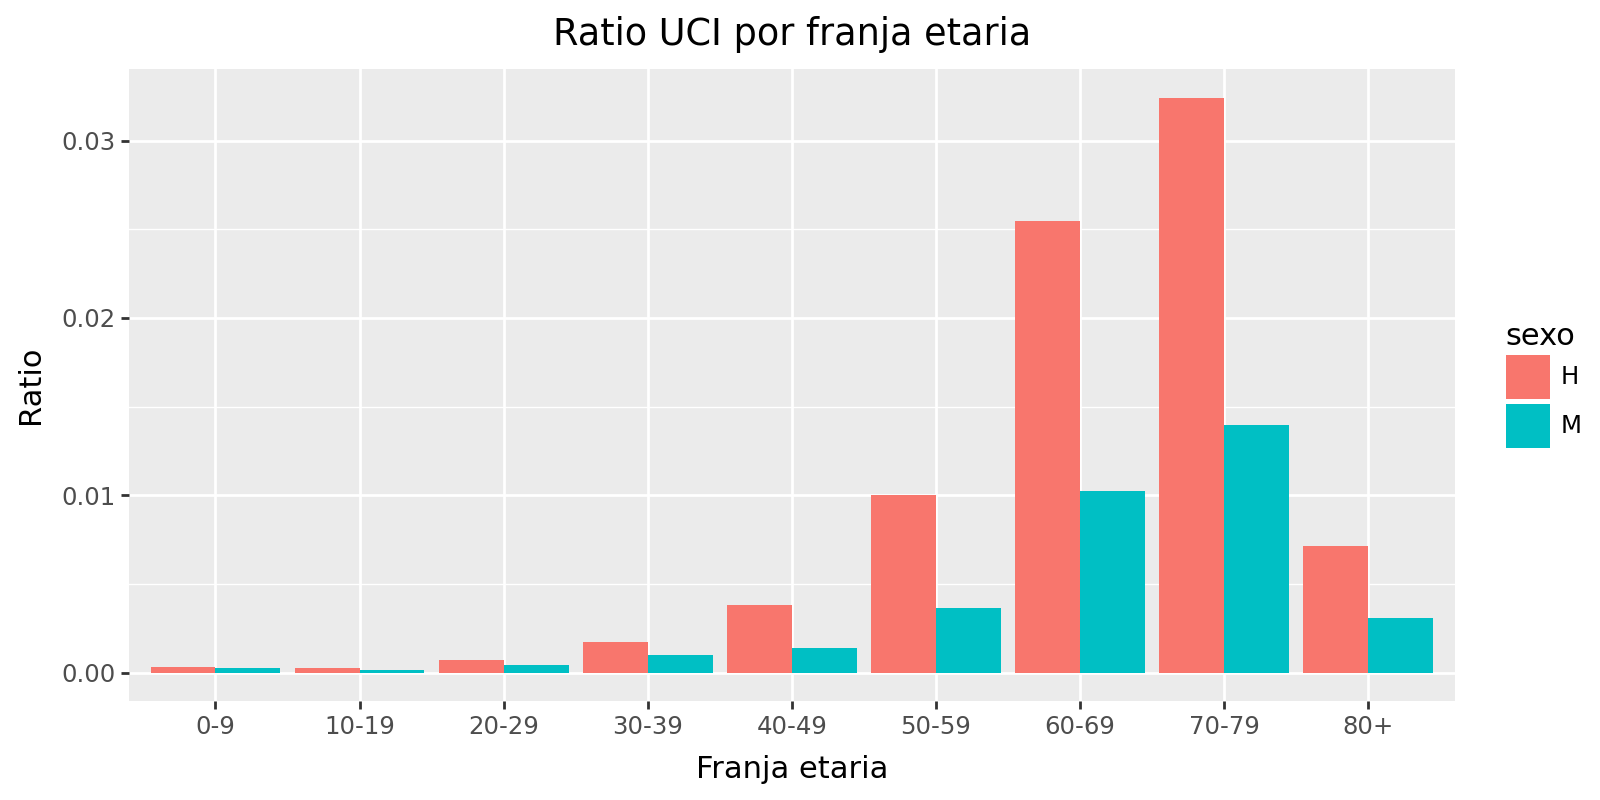

In [50]:
(
    ggplot(casos_franja_sexo)  
    + aes('franja_etaria', 
          'ratio_uci',
          fill = 'sexo')
    + geom_bar(position = "dodge",
               stat = "identity") 
    + labs(title='Ratio UCI por franja etaria', x='Franja etaria', y='Ratio')
    + theme(figure_size=(8, 4))
)

En ingreso a UCI notamos mayores ratios en hombres que en mujeres, especialmente en el rango 60-79 años.

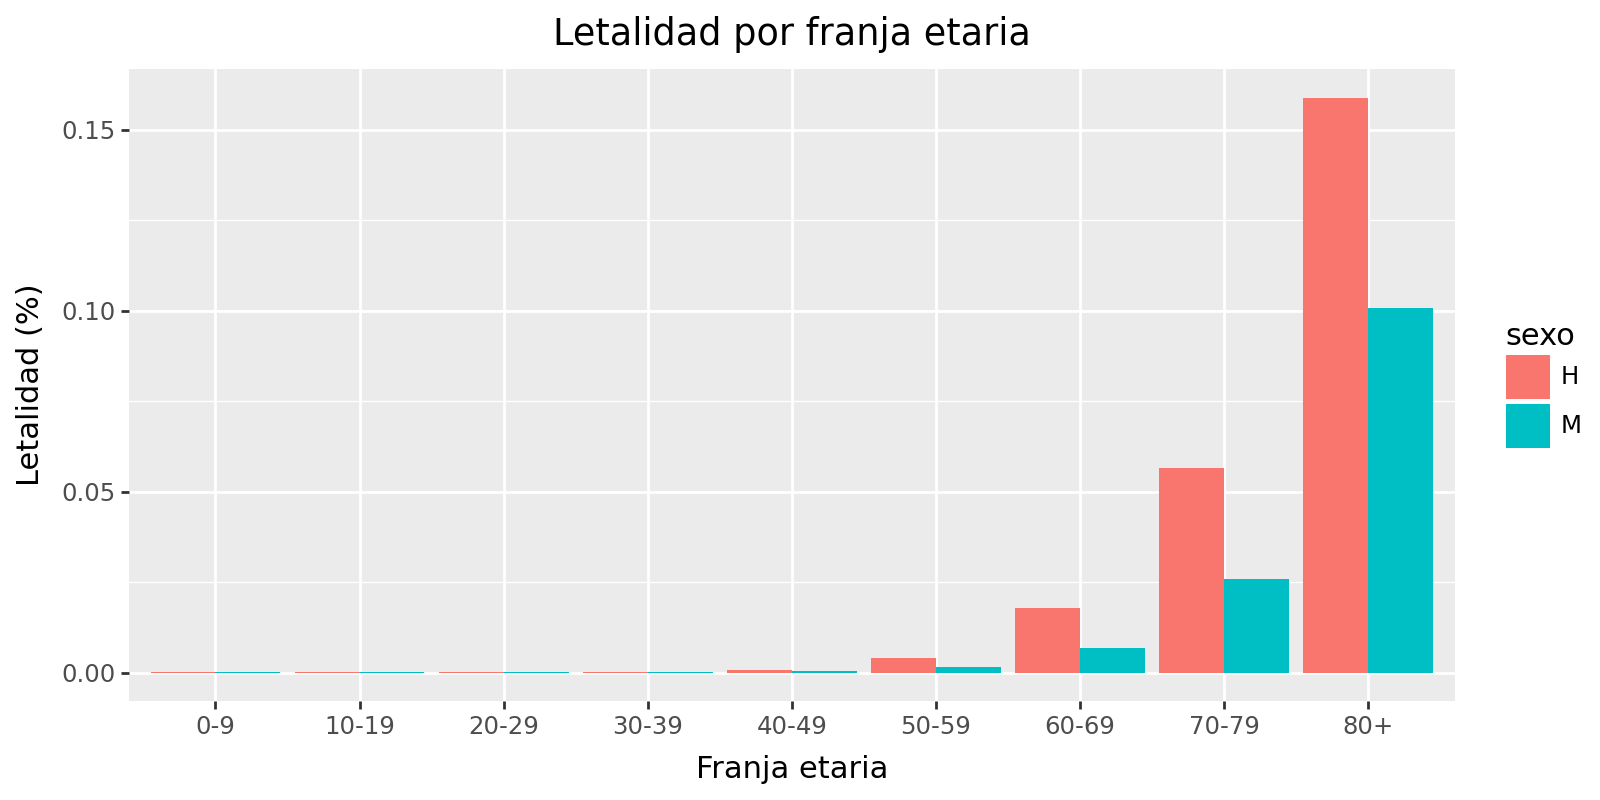

In [51]:
(
    ggplot(casos_franja_sexo)  
    + aes('franja_etaria', 
          'letalidad',
          fill = 'sexo')
    + geom_bar(position = 'dodge',
               stat = "identity") 
    #+ scale_y_continuous(labels='percent')
    + labs(title='Letalidad por franja etaria', x='Franja etaria', y='Letalidad (%)')
    + theme(figure_size=(8, 4))
    
)

La letalidad es evidentemente mayor en hombres que en mujeres, con un porcentaje importante, sobre todo en edades de 80 años en adelante, llegando a casi un 16%

### Franja etaria y provincia
Profundicemos un poco, esta vez viendo el comportamiento por franja etaria, pero teniendo en cuenta las provincias.

In [52]:
pob_periodo_franja_prv = pob_esp.groupby(['periodo','franja_etaria', 'sexo']).agg({'total':'sum'}).reset_index()

In [53]:
pob_geo = pob_esp.merge(map, how='left', left_on='postal_code', right_on='postal_code')

In [54]:
pob_geo.drop(columns=['edad', 'provincia_x', 'edad2', 'geometry'], inplace=True)
pob_geo.rename(columns={'provincia_y':'provincia'}, inplace=True)

In [55]:
pob_geo = pob_geo.groupby(['periodo',
                           'postal_code', 
                           'provincia', 
                           'franja_etaria']).agg({'total':'sum'}).reset_index()

In [56]:
casos_franja_prv = cov_prv.groupby(['periodo', 
                                     'franja_etaria', 
                                     'postal_code']).agg({'num_casos':'sum',
                                                   'num_hosp':'sum', 
                                                   'num_uci':'sum', 
                                                   'num_def':'sum'
                                                  }).reset_index()

In [57]:
casos_franja_prv = casos_franja_prv.merge(pob_geo, 
                                            how='left', 
                                            left_on=['periodo', 'franja_etaria', 'postal_code'], 
                                            right_on=['periodo', 'franja_etaria', 'postal_code'])

In [58]:
casos_franja_prv = casos_franja_prv.groupby(['franja_etaria'
                                               , 'provincia']).agg({'num_casos':'sum', 
                                                               'num_hosp':'sum', 
                                                               'num_uci':'sum', 
                                                               'num_def':'sum', 
                                                               'total':'mean'
                                                              }).reset_index()

In [59]:
casos_franja_prv.rename(columns={'total':'poblacion'}, inplace=True)

In [60]:
casos_franja_prv = casos_franja_prv[casos_franja_prv['franja_etaria']!='NC']
casos_franja_prv = casos_franja_prv.dropna(subset=['provincia'])

casos_franja_prv['ratio_casos'] = casos_franja_prv['num_casos']/casos_franja_prv['poblacion']
casos_franja_prv['ratio_hospitalizado'] = casos_franja_prv['num_hosp']/casos_franja_prv['num_casos']
casos_franja_prv['ratio_uci'] = casos_franja_prv['num_uci']/casos_franja_prv['num_casos']
casos_franja_prv['letalidad'] = casos_franja_prv['num_def']/casos_franja_prv['num_casos']

### Ratio contagios
Veamos el comportamiento de contagios por provincia y franja etaria.

In [61]:
hm_casos = casos_franja_prv[['provincia',
                      'franja_etaria',
                      'ratio_casos']]

Text(157.72222222222223, 0.5, 'Provincias')

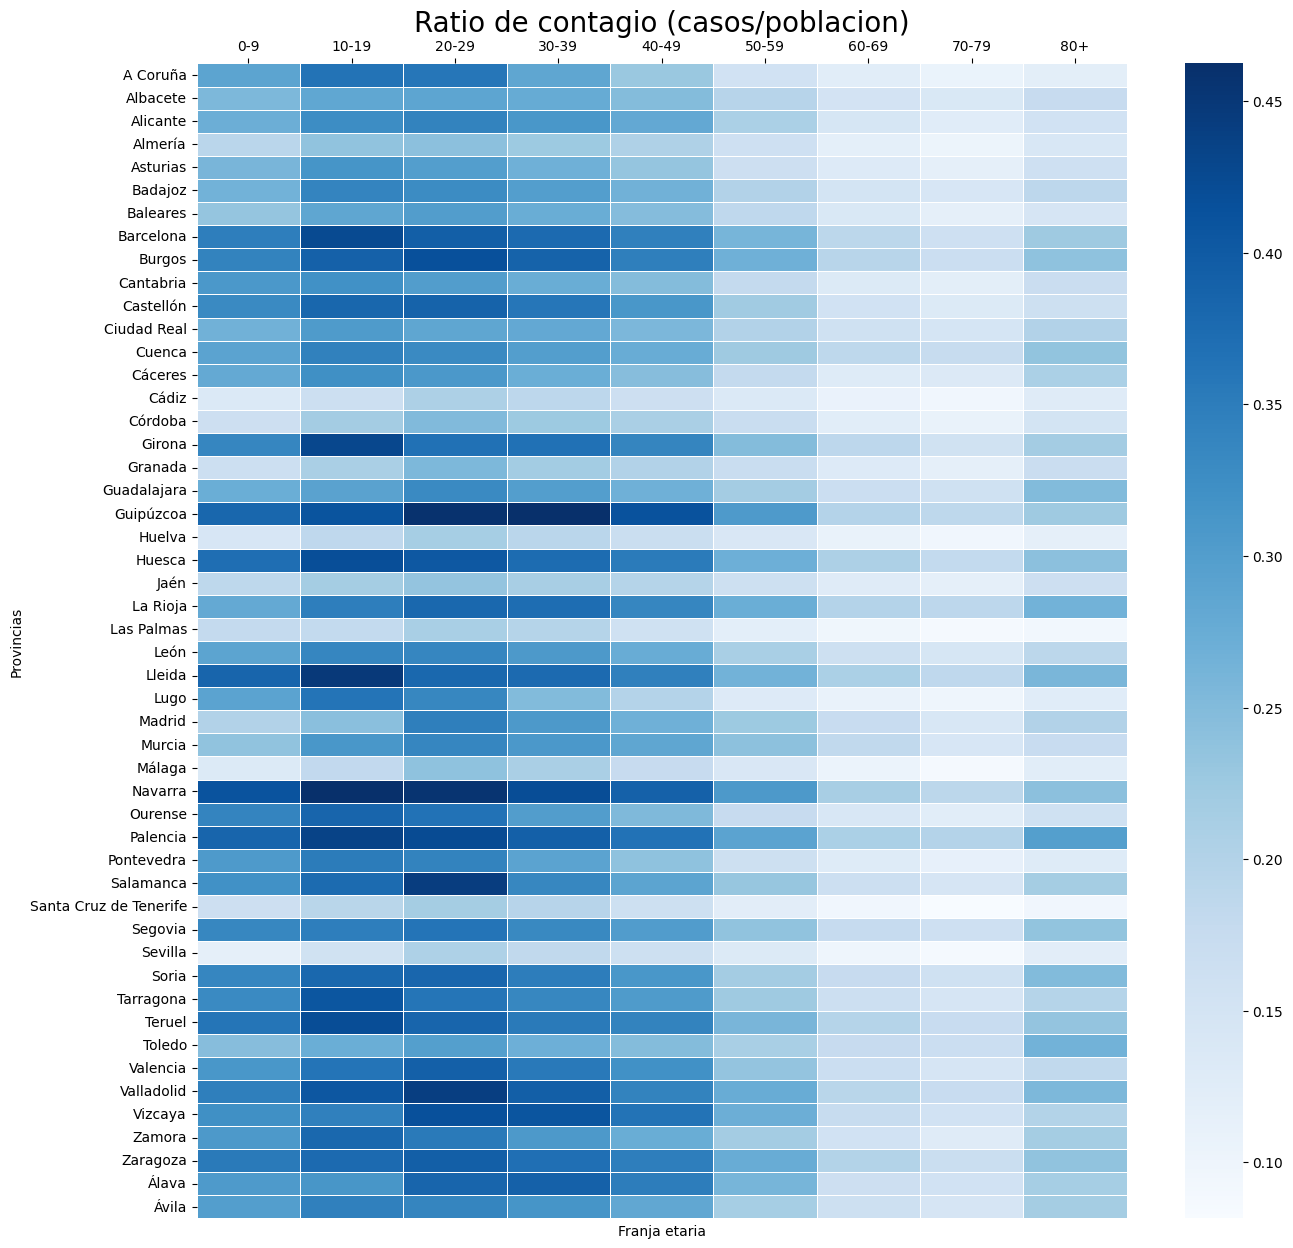

In [62]:
fig, ax = plt.subplots(figsize=(15,15))        
hm_casos = hm_casos.pivot(index = 'provincia', 
                          columns = 'franja_etaria', 
                          values = 'ratio_casos')
#mypalette = sns.color_palette("YlOrBr", as_cmap=True)
ax = sns.heatmap(hm_casos
                , cmap = 'Blues'
                #, annot=True
                , linewidth=.5
                )
ax.xaxis.tick_top()
ax.set_title('Ratio de contagio (casos/poblacion)', fontsize =20)
plt.xlabel('Franja etaria') 
plt.ylabel('Provincias') 



Este mapa de calor nos muestra un poco lo que ya habíamos visto antes, que los mayores ratios están en la zona de jovenes y adultos.

Sin embargo, podemos visualizar en qué provincias se sitúan esos puntos calientes. Por ejemplo, podemos ver que hay unos ratios mayores en las provincias de Guipúzcoa, Lleida, Navarra o Salamanca.

### Ratio de hospitalizados
Veamos el comportamiento de hospitalizados por provincia.

In [63]:
hm_hosp = casos_franja_prv[['provincia',
                      'franja_etaria',
                      'ratio_hospitalizado']]

Text(157.72222222222223, 0.5, 'Provincias')

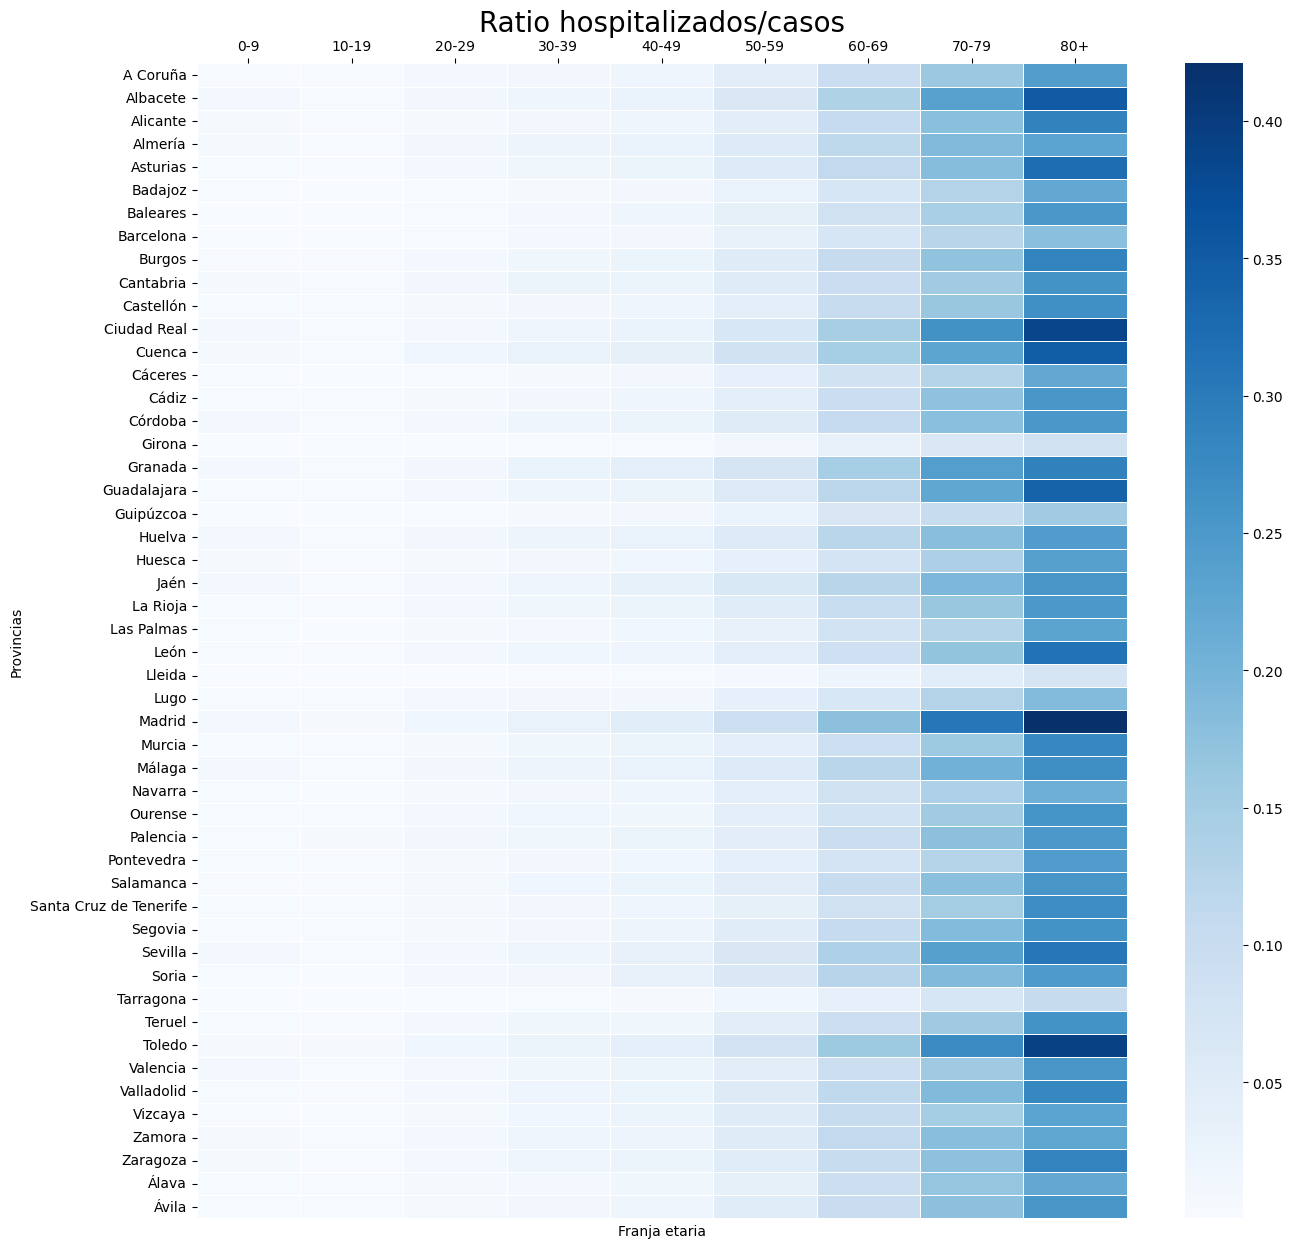

In [64]:
fig, ax = plt.subplots(figsize=(15,15))        
hm_hosp = hm_hosp.pivot(index = 'provincia', 
                          columns = 'franja_etaria', 
                          values = 'ratio_hospitalizado')
#mypalette = sns.color_palette("YlOrBr", as_cmap=True)
ax = sns.heatmap(hm_hosp
                , cmap = 'Blues'
                #, annot=True
                , linewidth=.5
                )
ax.xaxis.tick_top()
ax.set_title('Ratio hospitalizados/casos', fontsize =20)
plt.xlabel('Franja etaria') 
plt.ylabel('Provincias') 

Aquí podemos notar que hubo más hospitalizados por volumen de población en adultos mayores en las provincias de Ciudad Real, Madrid, Toledo y otras en menor medida.

### Ratio UCI
Veamos el comportamiento de ingresos en UCI por provincia.

In [65]:
hm_uci = casos_franja_prv[['provincia',
                      'franja_etaria',
                      'ratio_uci']]

Text(157.72222222222223, 0.5, 'Provincias')

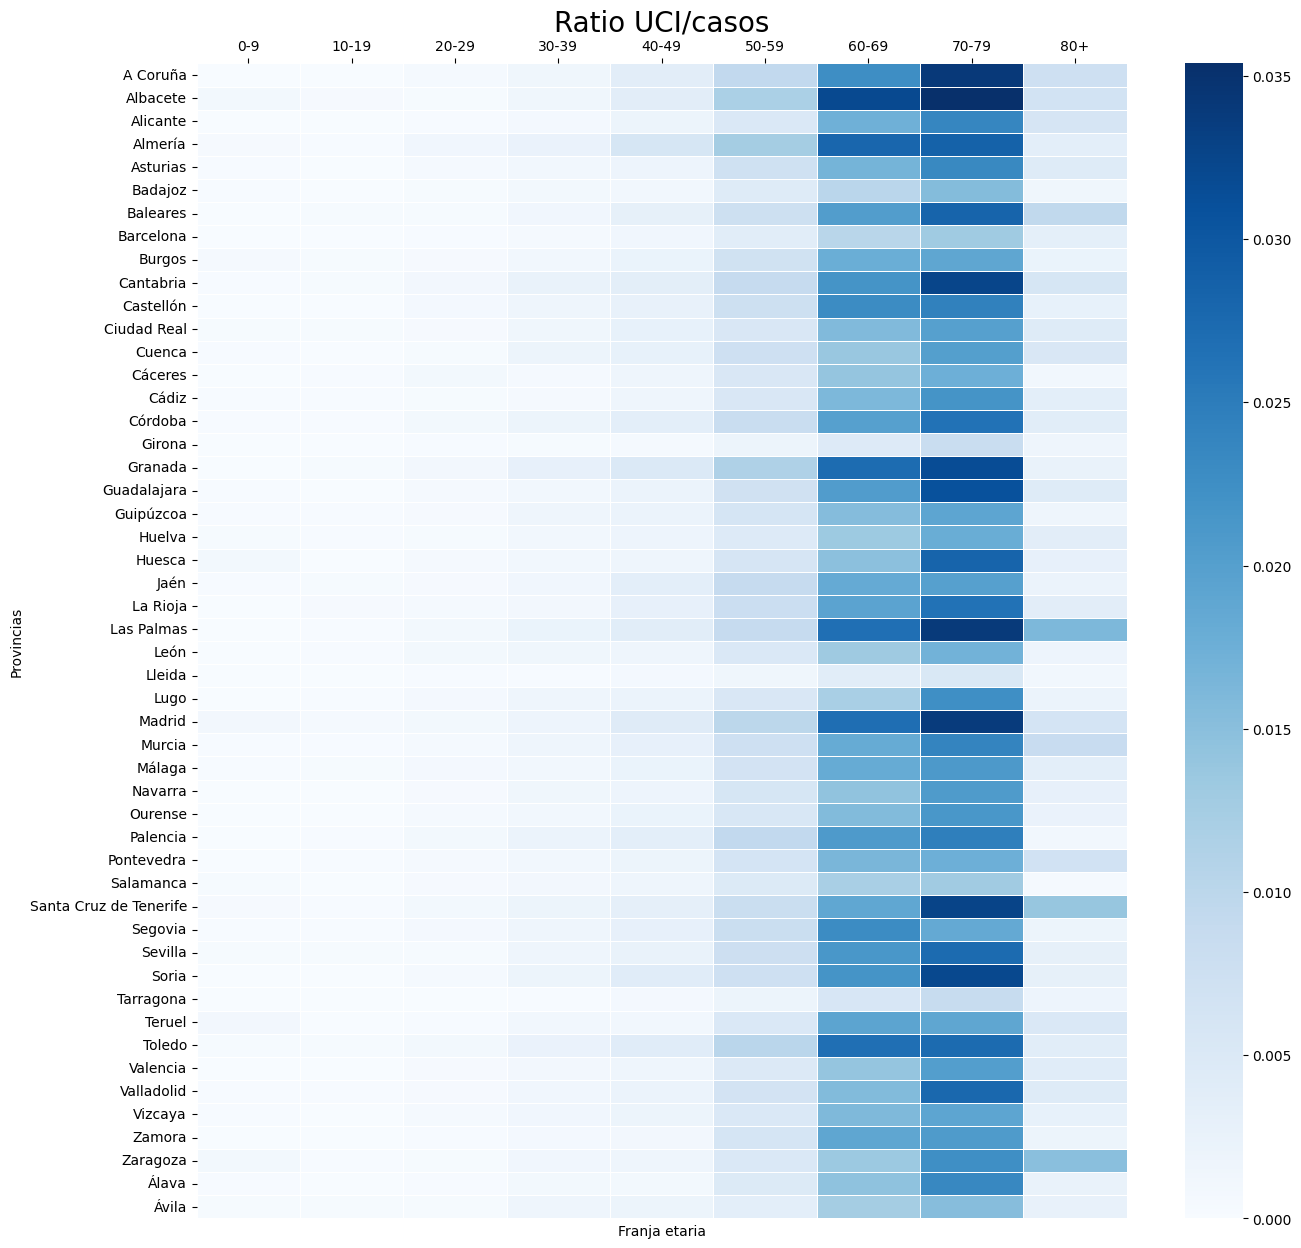

In [66]:
fig, ax = plt.subplots(figsize=(15,15))        
hm_uci = hm_uci.pivot(index = 'provincia', 
                          columns = 'franja_etaria', 
                          values = 'ratio_uci')
#mypalette = sns.color_palette("YlOrBr", as_cmap=True)
ax = sns.heatmap(hm_uci
                , cmap = 'Blues'
                #, annot=True
                , linewidth=.5
                )
ax.xaxis.tick_top()
ax.set_title('Ratio UCI/casos', fontsize =20)
plt.xlabel('Franja etaria') 
plt.ylabel('Provincias') 

El mayor ratio de ingresos en UCI por volumen de casos se encuentra en la franja de 70-79, como ya lo habíamos visto.

Sin embargo, este mapa de calor nos muestra en qué provincias es mayor este indicador: Albacete, A Coruña, Las Palmas, Madrid y otras en menor medida.

### Letalidad

In [67]:
hm_letal = casos_franja_prv[['provincia',
                      'franja_etaria',
                      'letalidad']]

Text(157.72222222222223, 0.5, 'Provincias')

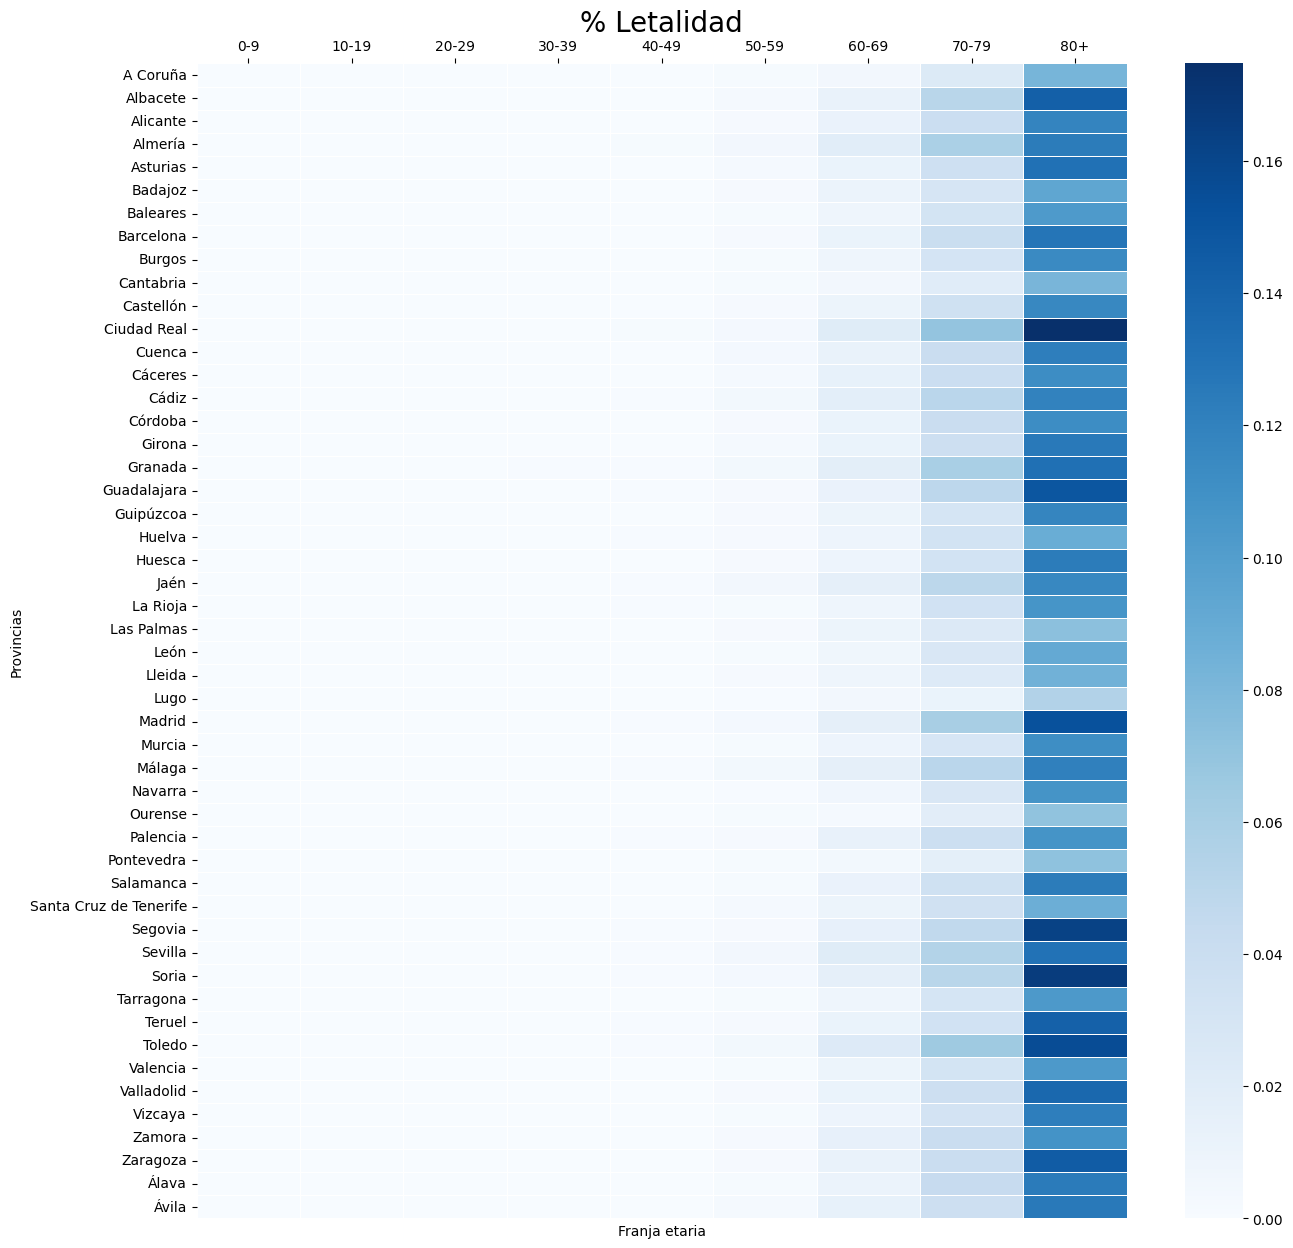

In [68]:
fig, ax = plt.subplots(figsize=(15,15))        
hm_letal = hm_letal.pivot(index = 'provincia', 
                          columns = 'franja_etaria', 
                          values = 'letalidad')
#mypalette = sns.color_palette("YlOrBr", as_cmap=True)
ax = sns.heatmap(hm_letal
                , cmap = 'Blues'
                #, annot=True
                , linewidth=.5
                )
ax.xaxis.tick_top()
ax.set_title('% Letalidad', fontsize =20)
plt.xlabel('Franja etaria') 
plt.ylabel('Provincias') 

La mayor letalidad se encuentra en la franja de 80 años o más, como ya lo habíamos visto.

Sin embargo, este mapa de calor nos muestra en qué provincias es mayor este indicador: Ciudad Real, Soria, Segovia, Toledo y otras en menor medida.

### Incidencia acumulada total por cada cien habitantes
Analizaremos de forma gráfica la incidencia por cada cien habitantes durante toda la pandemia.

Para ello, pintaremos en un mapa las distintas provincias de España indicando este indicador en una escala de colores.

In [69]:
casos_pc = cov_prv.groupby(['periodo', 
                          'postal_code']).agg({'num_casos':'sum', 
                                                'num_hosp':'sum', 
                                                'num_uci':'sum', 
                                                'num_def':'sum'
                                               }).reset_index()


In [70]:
casos_pob = pd.merge(casos_pc, 
              poblacion, 
              how='left', 
              left_on=['periodo', 'postal_code'], 
              right_on = ['periodo', 'postal_code'], 
              suffixes=('_x', '_y')
             )

In [71]:
casos_pob = casos_pob.groupby(['postal_code']).agg({'num_casos':'sum', 
                                                    'num_hosp':'sum', 
                                                    'num_uci':'sum', 
                                                    'num_def':'sum',
                                                    'total':'mean'
                                                   }).reset_index()

In [72]:
casos_pob['incidencia'] = casos_pob['num_casos']/casos_pob['total']*100
casos_pob['incidencia'] = casos_pob['incidencia'].round(2)
casos_pob['total'] = casos_pob['total'].round(2)

In [73]:
casos_geo = casos_pob.merge(map, how='left', left_on='postal_code', right_on='postal_code')
casos_geo.dropna(subset=['geometry'], inplace=True)
casos_geo.rename(columns={'total':'poblacion'}, inplace = True)
gdf = gpd.GeoDataFrame(casos_geo, geometry=casos_geo.geometry)

In [74]:
# IA Total por cada cien habitantes
m = gdf.explore(
     column="incidencia",  
     scheme="naturalbreaks",  
     legend=True, 
     k=10, 
     legend_kwds=dict(colorbar=True), 
     name="countries", 
     tooltip=['comunidad_autonoma', 'provincia', 'incidencia'],
     cmap='Blues'
)

folium.TileLayer('OpenStreetMap', control=True).add_to(m)  
folium.LayerControl().add_to(m) 

m  # show map

Podemos observar en el mapa, cuáles son las provincias con mayor incidencia acumulada.

Por ejemplo, provincias como Navarra, Guipúzcoa, Lleida o Palencia, cuyas IA son visiblemente mayores que las demás regiones geográficas.


### Conclusiones
- La pandemia ha presentado incrementos importantes de casos en periodos específicos a lo largo del tiempo, identificándose como olas de la pandemia. La sexta (comprendida entre octubre de 2021 y marzo de 2022) especialmente ha tenido un pico importante, superando ampliamente el umbral de riesgo muy alto.
- Cabe destacar una marcada diferencia en casos entre hombres y mujeres durante la última ola, cuyos números femeninos superan a los casos masculinos.
- La mayor cantidad de casos se concentró en la franja de jóvenes y adultos (0 a 49 años), esto se verifica también analizando el ratio de casos de población por franja etaria. 
- Teniendo en cuenta ratios de hospitalizaciones, podemos decir que la franja más afectada es la de 60 años o más. Cabe mencionar también que en casi todas las franjas etarias, vemos un mayor ratio de hombres hospitalizados, incrementándose a mayor edad. 
- En ingreso a UCI notamos mayores ratios en hombres que en mujeres, especialmente en el rango 60-79 años.
- La letalidad es claramente mayor en la franja de 60 años en adelante, siendo mayor en hombres que en mujeres.
- Analizando la incidencia acumulada por cada cien habitantes, destacamos en el top 3 con mayor IA a las provincias de Navarra, Guipúzcoa y Lleida.